# EDA — bronze & silver data

Exploratory analysis of the data acquired by `build_dataset.ipynb`, before the gold (feature/stamp) fetch.
Focus: **class distribution**, label provenance, and the quality/coverage of the silver ground-truth table.

- **Bronze** = the five raw catalogues, as downloaded.
- **Silver** = `labelled_objects.parquet` — one cleaned, labelled, ZTF-resolved object per row.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA = Path('data')
BRONZE, SILVER = DATA/'bronze', DATA/'silver'

# consistent colours for the three coarse classes
COARSE_COLORS = {'SN':'#d1495b', 'AGN':'#30638e', 'VS':'#edae49'}

def bar_labels(ax, fmt='{:,.0f}'):
    """annotate each bar with its height"""
    for p in ax.patches:
        h = p.get_height()
        if h and not np.isnan(h):
            ax.annotate(fmt.format(h), (p.get_x()+p.get_width()/2, h),
                        ha='center', va='bottom', fontsize=9, xytext=(0,2),
                        textcoords='offset points')
print('setup ready')

setup ready


## Load data

Silver is the main object of study; bronze is loaded to inspect raw labels and matching yield.

In [2]:
silver = pd.read_parquet(SILVER/'labelled_objects.parquet')

bronze = {}
def _try(name, fn):
    try:
        bronze[name] = fn(); print(f'{name:10s}: {len(bronze[name]):>7,} rows')
    except Exception as e:
        bronze[name] = None; print(f'{name:10s}: skipped ({e})')

_try('bts',       lambda: pd.read_csv(BRONZE/'bts.csv', na_values=['-','']))
_try('tns',       lambda: pd.read_csv(BRONZE/'tns_public_objects.csv'))
_try('chen',      lambda: pd.read_parquet(BRONZE/'chen_vs.parquet'))
_try('milliquas', lambda: pd.read_parquet(BRONZE/'milliquas.parquet'))
_try('sdss',      lambda: pd.read_parquet(BRONZE/'sdss_dr16q.parquet'))

print('\nsilver:', silver.shape)
silver.head()

bts       :  20,475 rows
tns       : 198,828 rows
chen      : 200,000 rows
milliquas : 150,000 rows
sdss      : 150,000 rows

silver: (14378, 10)


,source,ext_name,ra,dec,redshift,raw_type,coarse,fine,oid,plasticc_class
0,bts,SN2019hbt,205.792875,30.343417,0.03474,SN II,SN,SN II,ZTF19aaydtur,SNII
1,bts,SN2020qxz,271.001042,74.013944,0.09640,SN Ia-CSM,SN,SN Ia-CSM,ZTF20abqkbfx,None
2,bts,SN2020faa,221.789500,72.736528,0.04106,SN II,SN,SN II,ZTF20aatqesi,SNII
3,bts,SN2022pag,325.171375,-7.515000,0.03200,SN Ia,SN,SN Ia,ZTF22aaudeny,SNIa
4,bts,SN2019nwf,61.270708,-6.604806,0.05700,SN Ia,SN,SN Ia,ZTF19abqlrtb,SNIa


## Silver overview

Schema, dtypes, and missingness of the unified table.

In [3]:
print('rows x cols:', silver.shape)
display(silver.dtypes.to_frame('dtype'))

miss = (silver.isna().mean()*100).round(1).sort_values(ascending=False)
miss.to_frame('% missing')

rows x cols: (14378, 10)


,dtype
source,object
ext_name,object
ra,float64
dec,float64
redshift,float64
raw_type,object
coarse,object
fine,object
oid,object
plasticc_class,object


,% missing
ext_name,30.3
redshift,27.9
plasticc_class,15.5
source,0.0
dec,0.0
ra,0.0
raw_type,0.0
coarse,0.0
fine,0.0
oid,0.0


## Coarse class distribution

The three head-to-head training classes (SN / AGN / VS). This is the headline balance figure.

        count   pct
coarse             
SN       9403  65.4
VS       4221  29.4
AGN       754   5.2

imbalance ratio (max/min): 12.5x


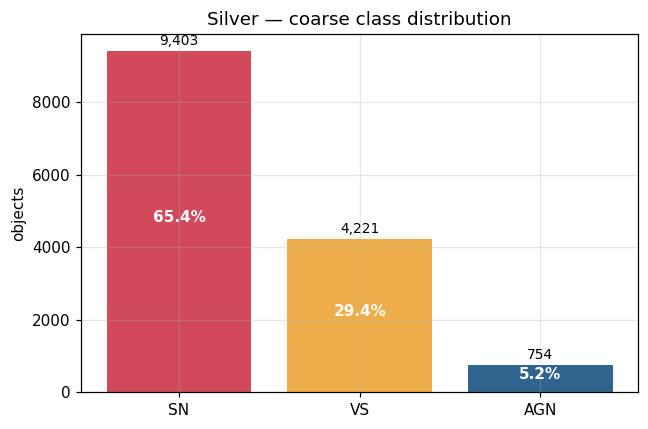

In [4]:
vc = silver['coarse'].value_counts()
pct = (vc/vc.sum()*100).round(1)
summary = pd.DataFrame({'count':vc, 'pct':pct})
print(summary)
print(f"\nimbalance ratio (max/min): {vc.max()/vc.min():.1f}x")

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(vc.index, vc.values, color=[COARSE_COLORS[c] for c in vc.index])
ax.set_ylabel('objects'); ax.set_title('Silver — coarse class distribution')
bar_labels(ax)
for i,c in enumerate(vc.index):
    ax.annotate(f'{pct[c]}%', (i, vc[c]/2), ha='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()

## Fine class distribution

Subtypes, coloured by their coarse parent. Shows which subtypes dominate (e.g. SN Ia, EB).

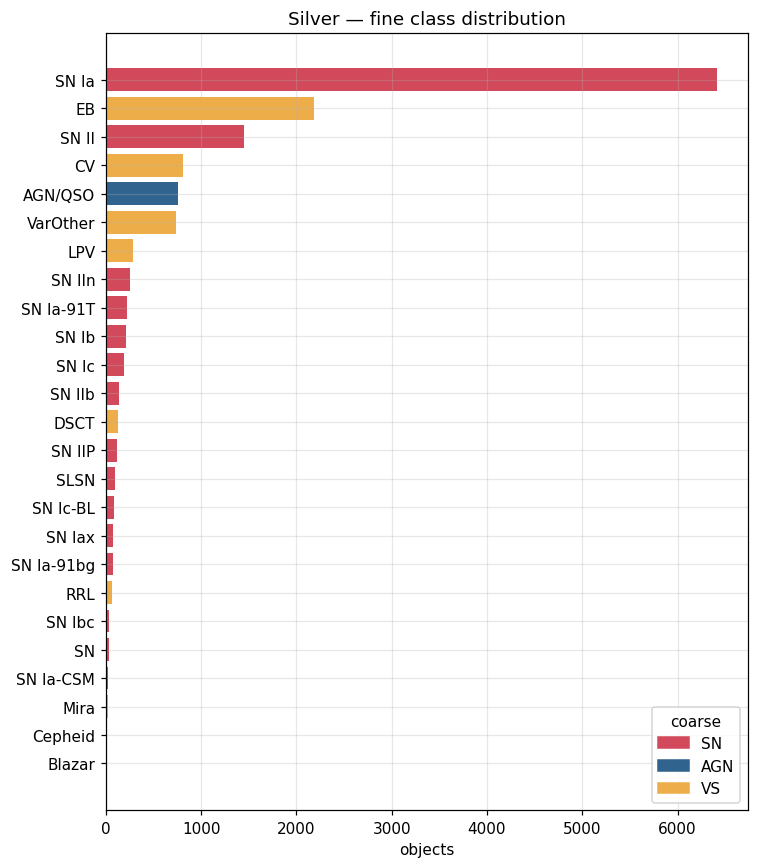

,count
fine,
SN Ia,6419
EB,2181
SN II,1450
CV,809
AGN/QSO,753
VarOther,734
LPV,280
SN IIn,251
SN Ia-91T,216


In [5]:
# map each fine label to its coarse parent for colouring
fine_to_coarse = (silver.dropna(subset=['fine'])
                  .groupby('fine')['coarse'].agg(lambda x: x.mode().iat[0]))
fvc = silver['fine'].value_counts()
colors = [COARSE_COLORS.get(fine_to_coarse.get(f), '#999999') for f in fvc.index]

fig, ax = plt.subplots(figsize=(7, max(4, 0.32*len(fvc))))
ax.barh(fvc.index[::-1], fvc.values[::-1], color=colors[::-1])
ax.set_xlabel('objects'); ax.set_title('Silver — fine class distribution')
handles = [plt.Rectangle((0,0),1,1,color=COARSE_COLORS[c]) for c in COARSE_COLORS]
ax.legend(handles, COARSE_COLORS.keys(), title='coarse', loc='lower right')
plt.tight_layout(); plt.show()
fvc.to_frame('count')

## Label provenance — which catalogue labelled what

Each class is sourced from independent (non-broker) catalogues. This crosstab is the evidence of that, and exposes any single-source dependence.

coarse     AGN    SN    VS
source                    
bts          0  8000     0
chen_vs      0     0  3735
milliquas  307     0     0
sdss       311     0     0
tns        136  1403   486


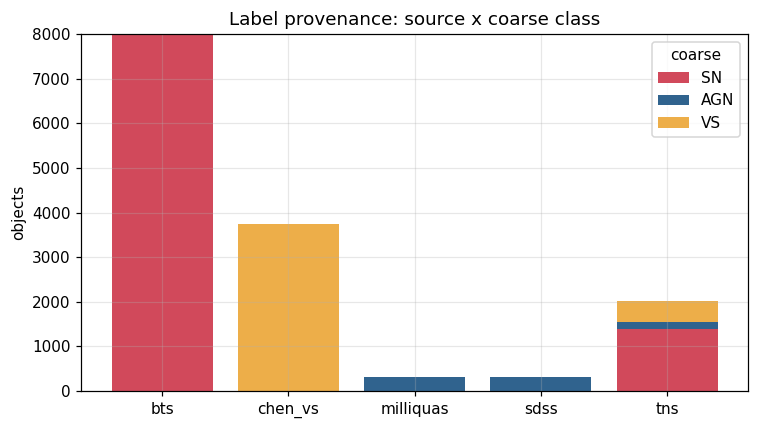

In [6]:
ct = pd.crosstab(silver['source'], silver['coarse'])
print(ct)

fig, ax = plt.subplots(figsize=(7,4))
bottom = np.zeros(len(ct))
for c in ['SN','AGN','VS']:
    if c in ct.columns:
        ax.bar(ct.index, ct[c], bottom=bottom, label=c, color=COARSE_COLORS[c])
        bottom += ct[c].values
ax.set_ylabel('objects'); ax.set_title('Label provenance: source x coarse class')
ax.legend(title='coarse'); plt.tight_layout(); plt.show()

## PLAsTiCC mapping coverage

How many objects carry a `plasticc_class` (used for the simulated-vs-real RQ3 comparison).

In [7]:
cov = silver['plasticc_class'].notna().mean()*100
print(f'objects with a plasticc_class: {cov:.1f}%')
silver['plasticc_class'].value_counts(dropna=False).to_frame('count')

objects with a plasticc_class: 84.5%


,count
plasticc_class,
SNIa,6419
None,2226
EB,2181
SNII,1953
AGN,754
SNIbc,518
SLSN-I,96
SNIax,79
SNIa-91bg,72


## Redshift distribution

Sanity check: SNe and AGN should carry redshifts (extragalactic); variable stars should mostly not (Galactic).

fraction with a redshift:
coarse
AGN    0.995
SN     0.998
VS     0.057
Name: redshift, dtype: float64


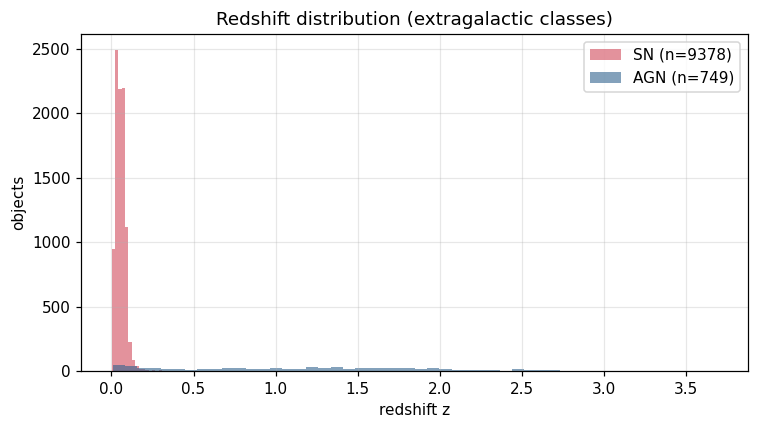

In [8]:
frac = silver.groupby('coarse')['redshift'].apply(lambda x: x.notna().mean()).round(3)
print('fraction with a redshift:'); print(frac)

fig, ax = plt.subplots(figsize=(7,4))
for c in ['SN','AGN']:
    z = silver.loc[silver['coarse']==c, 'redshift'].dropna()
    z = z[(z>0)&(z<4)]
    if len(z):
        ax.hist(z, bins=50, alpha=0.6, label=f'{c} (n={len(z)})', color=COARSE_COLORS[c])
ax.set_xlabel('redshift z'); ax.set_ylabel('objects')
ax.set_title('Redshift distribution (extragalactic classes)')
ax.legend(); plt.tight_layout(); plt.show()

## Sky distribution

Positions coloured by class. Variable stars should trace the Galactic plane; SNe/AGN should be more isotropic.

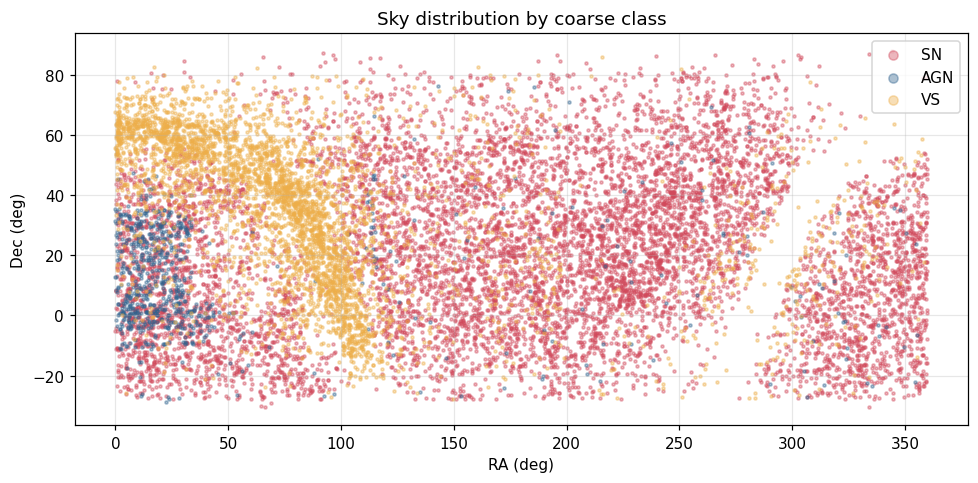

In [9]:
fig, ax = plt.subplots(figsize=(9,4.5))
for c in ['SN','AGN','VS']:
    sub = silver[silver['coarse']==c]
    ax.scatter(sub['ra'], sub['dec'], s=4, alpha=0.4, label=c, color=COARSE_COLORS[c])
ax.set_xlabel('RA (deg)'); ax.set_ylabel('Dec (deg)')
ax.set_title('Sky distribution by coarse class'); ax.legend(markerscale=3)
plt.tight_layout(); plt.show()

## Bronze — raw label distributions

The raw `type`/`Type` columns *before* mapping, so the taxonomy mapping in silver can be audited against the source vocabulary.

In [10]:
def show_raw(name, col, top=15):
    df = bronze.get(name)
    if df is None or col not in df.columns:
        print(f'{name}: no column {col!r}'); return
    print(f'--- {name}.{col} (top {top} of {df[col].nunique()} unique) ---')
    print(df[col].value_counts(dropna=False).head(top), '\n')

show_raw('bts', 'type')
show_raw('tns', 'type')
show_raw('chen', 'Type')
show_raw('milliquas', 'Type')
show_raw('sdss', 'Class')

--- bts.type (top 15 of 40 unique) ---
type
SN Ia         7892
NaN           7564
SN II         1735
CV             684
AGN            404
SN IIn         302
SN Ia-91T      262
SN Ic          224
SN Ib          191
SN IIb         162
CV?            156
SN IIP         136
SLSN-I         111
SN Ic-BL        96
SN Ia-91bg      76
Name: count, dtype: int64 

--- tns.type (top 15 of 55 unique) ---
type
NaN                172989
SN Ia               12562
FRB                  5129
SN II                3044
CV                    624
SN IIn                551
SN Ia-91T-like        483
SN Ic                 422
SN Ib                 335
SN IIP                320
SN IIb                305
SLSN-I                223
SN Ic-BL              187
SN Ia-91bg-like       168
AGN                   161
Name: count, dtype: int64 

--- chen.Type (top 15 of 11 unique) ---
Type
EW       104633
BYDra     28194
RSCVN     22523
SR        13448
EA        13209
RR         7822
DSCT       5624
RRc        3025
Mira    

## Cross-match yield (bronze → silver)

How many raw catalogue rows survived ZTF oid-resolution + dedup into silver. Low AGN yield here explains the class imbalance above.

In [11]:
raw_counts = {k:(0 if v is None else len(v)) for k,v in bronze.items()}
silver_by_src = silver['source'].value_counts().to_dict()

# map silver source names back to bronze keys
alias = {'chen_vs':'chen'}
rows = []
for src, kept in silver_by_src.items():
    bkey = alias.get(src, src)
    raw = raw_counts.get(bkey, np.nan)
    rows.append({'source':src, 'silver_kept':kept, 'bronze_raw':raw,
                 'yield_%': round(100*kept/raw,2) if raw else np.nan})
pd.DataFrame(rows).sort_values('silver_kept', ascending=False)

,source,silver_kept,bronze_raw,yield_%
0,bts,8000,20475,39.07
1,chen_vs,3735,200000,1.87
2,tns,2025,198828,1.02
3,sdss,311,150000,0.21
4,milliquas,307,150000,0.20


## Takeaways

Fill in after running, but the analysis is built to surface:

- **Class imbalance** — SN dominate, AGN are the minority (cone-search yield is the bottleneck). Plan: class weighting / resampling, and report per-class metrics, not just accuracy.
- **Single-source classes** — VS come almost entirely from Chen, SN from BTS. Note this as a provenance caveat.
- **Label sanity** — redshift presence and sky distribution should match the physical expectation (extragalactic vs Galactic).
- **Taxonomy audit** — raw bronze vocabularies vs the mapped fine labels.
